## Imports

In [86]:
import os
import json
from datetime import datetime

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
from scipy.io import savemat

import importlib
import kan

importlib.reload(kan)

<module 'kan' from '/Users/sofijaorlovic/Desktop/sofka/Kolmogorov-Arnold Networks (KAN) - diplomski/photonic-KAN/kan.py'>

## Load photonic activation

In [87]:
mat_path = "activation_KAN_fit_B_Sofija_extend_positive_basisKAN.mat"

b_coef, input_power, peakout_data, set_detuning = kan.load_photonic_activation_data(mat_path)

selected_indices = np.array([1, 3, 7])

b_coef_selected = b_coef[selected_indices]

print("Selected indices:", selected_indices)
print("Selected detunings:", set_detuning[selected_indices])
print("Selected b_coef shape:", b_coef_selected.shape)

print("input_power min:", input_power.min().item())
print("input_power max:", input_power.max().item())

mat_folder = "kan_iris_positive_export"
os.makedirs(mat_folder, exist_ok=True)

Selected indices: [1 3 7]
Selected detunings: tensor([-6.0000e+10, -8.0000e+10, -1.2000e+11])
Selected b_coef shape: torch.Size([3, 8])
input_power min: 0.0
input_power max: 60.0


## Load Iris data

In [88]:
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", iris.target_names)
print("Features:", iris.feature_names)

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## Train/test split

In [89]:
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

x_min_physical = 0.0
x_max_physical = 1.0

scaler = MinMaxScaler(feature_range=(x_min_physical, x_max_physical))

X_train_scaled = scaler.fit_transform(X_train_original)
X_test_scaled = scaler.transform(X_test_original)

X_train_scaled = np.clip(X_train_scaled, x_min_physical, x_max_physical)
X_test_scaled = np.clip(X_test_scaled, x_min_physical, x_max_physical)

print("X_train_scaled min/max:", X_train_scaled.min(), X_train_scaled.max())
print("X_test_scaled min/max:", X_test_scaled.min(), X_test_scaled.max())

X_train_scaled min/max: 0.0 1.0
X_test_scaled min/max: 0.0 0.9583333333333334


In [90]:
x_min=0.0
x_max=1.0
check_input_range=True

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

print("X_train_t:", X_train_t.shape)
print("y_train_t:", y_train_t.shape)

Using device: cpu
X_train_t: torch.Size([112, 4])
y_train_t: torch.Size([112])


## KAN model

In [92]:
model = kan.KAN(
    in_count=4,
    out_count=3,
    hidden_layer_sizes=[],
    layer_type="photonic_positive",
    b_coef_selected=b_coef_selected,
    x_min=x_min_physical,
    x_max=x_max_physical,
    dropout_prob=0.0,
    normalize_basis=False,
    check_input_range=True,
    debug=False,
    coeff_eps=1e-9,
).to(device)

print(model)

KAN(
  (layers): ModuleList(
    (0): PhotonicBasisActivationLayerPositive()
  )
)


In [93]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 3000

train_loss_history = []
test_loss_history = []

train_acc_history = []
test_acc_history = []

for epoch in range(epochs):
    # -------------------------
    # Training step
    # -------------------------
    model.train()

    optimizer.zero_grad()

    train_logits = model(X_train_t)
    train_loss = loss_fn(train_logits, y_train_t)

    train_loss.backward()
    optimizer.step()

    # -------------------------
    # Evaluation step
    # -------------------------
    model.eval()

    with torch.no_grad():
        # Train metrics after update
        train_logits_eval = model(X_train_t)
        train_loss_eval = loss_fn(train_logits_eval, y_train_t)

        train_pred = torch.argmax(train_logits_eval, dim=1)
        train_acc = (train_pred == y_train_t).float().mean().item()

        # Test metrics
        test_logits = model(X_test_t)
        test_loss = loss_fn(test_logits, y_test_t)

        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = (test_pred == y_test_t).float().mean().item()

    train_loss_history.append(train_loss_eval.item())
    test_loss_history.append(test_loss.item())

    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Train loss: {train_loss_eval.item():.6f} | "
            f"Test loss: {test_loss.item():.6f} | "
            f"Train acc: {train_acc:.4f} | "
            f"Test acc: {test_acc:.4f}"
        )

Epoch    0 | Train loss: 1.099374 | Test loss: 1.099782 | Train acc: 0.3304 | Test acc: 0.3158
Epoch  100 | Train loss: 0.690994 | Test loss: 0.726383 | Train acc: 0.9196 | Test acc: 0.9474
Epoch  200 | Train loss: 0.507586 | Test loss: 0.560950 | Train acc: 0.9643 | Test acc: 0.8947
Epoch  300 | Train loss: 0.406573 | Test loss: 0.468497 | Train acc: 0.9643 | Test acc: 0.8684
Epoch  400 | Train loss: 0.343121 | Test loss: 0.409388 | Train acc: 0.9732 | Test acc: 0.8684
Epoch  500 | Train loss: 0.299116 | Test loss: 0.367589 | Train acc: 0.9732 | Test acc: 0.8684
Epoch  600 | Train loss: 0.266415 | Test loss: 0.335904 | Train acc: 0.9732 | Test acc: 0.8684
Epoch  700 | Train loss: 0.240890 | Test loss: 0.310688 | Train acc: 0.9732 | Test acc: 0.8947
Epoch  800 | Train loss: 0.220241 | Test loss: 0.289897 | Train acc: 0.9732 | Test acc: 0.8947
Epoch  900 | Train loss: 0.203088 | Test loss: 0.272297 | Train acc: 0.9732 | Test acc: 0.9211
Epoch 1000 | Train loss: 0.188547 | Test loss: 0.2

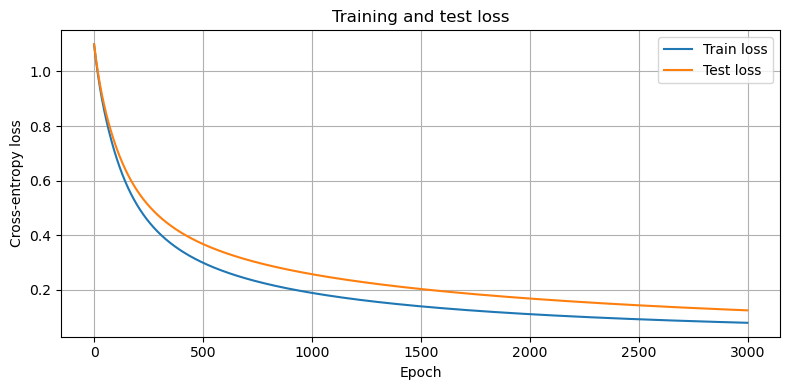

In [94]:
savemat(
    os.path.join(mat_folder, "loss_curves.mat"),
    {
        "plot_type": "loss_curves",
        "epoch": np.arange(epochs),
        "train_losses": np.array(train_loss_history),
        "test_losses": np.array(test_loss_history),
        "num_epochs": epochs,
    },
)

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label="Train loss")
plt.plot(test_loss_history, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and test loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

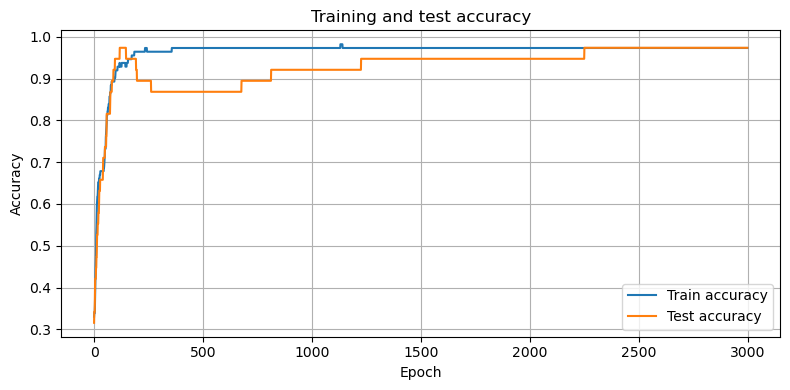

In [95]:
savemat(
    os.path.join(mat_folder, "accuracy_curves.mat"),
    {
        "plot_type": "accuracy_curves",
        "epoch": np.arange(epochs),
        "train_accuracies": np.array(train_acc_history),
        "test_accuracies": np.array(test_acc_history),
        "num_epochs": epochs,
    },
)

plt.figure(figsize=(8, 4))
plt.plot(train_acc_history, label="Train accuracy")
plt.plot(test_acc_history, label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and test accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
model.eval()

with torch.no_grad():
    train_logits = model(X_train_t)
    train_pred = torch.argmax(train_logits, dim=1)
    train_acc = (train_pred == y_train_t).float().mean().item()

    test_logits = model(X_test_t)
    test_pred = torch.argmax(test_logits, dim=1)
    test_acc = (test_pred == y_test_t).float().mean().item()

savemat(
    os.path.join(mat_folder, "final_predictions.mat"),
    {
        "plot_type": "final_predictions",
        "y_test": y_test_t.cpu().numpy(),
        "test_pred": test_pred.cpu().numpy(),
        "y_train": y_train_t.cpu().numpy(),
        "train_pred": train_pred.cpu().numpy(),
    },
)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

test_pred_np = test_pred.cpu().numpy()
y_test_np = y_test_t.cpu().numpy()

print("Confusion matrix:")
print(confusion_matrix(y_test_np, test_pred_np))

print("\nClassification report:")
print(
    classification_report(
        y_test_np,
        test_pred_np,
        target_names=iris.target_names,
    )
)

Train accuracy: 0.9732142686843872
Test accuracy: 0.9736841917037964
Confusion matrix:
[[12  0  0]
 [ 0 12  1]
 [ 0  0 13]]

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out0_in0.mat


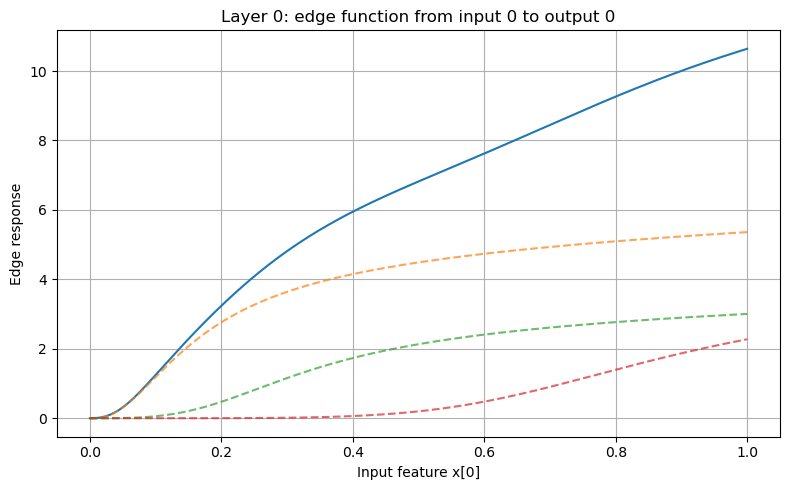

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out1_in0.mat


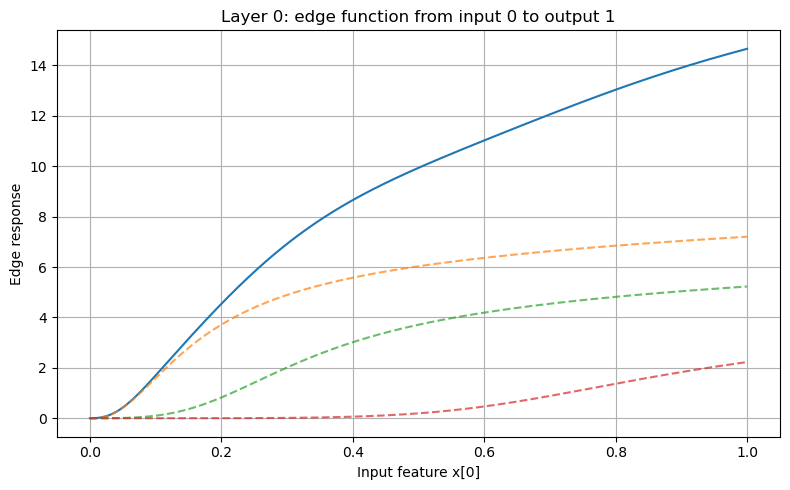

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out2_in0.mat


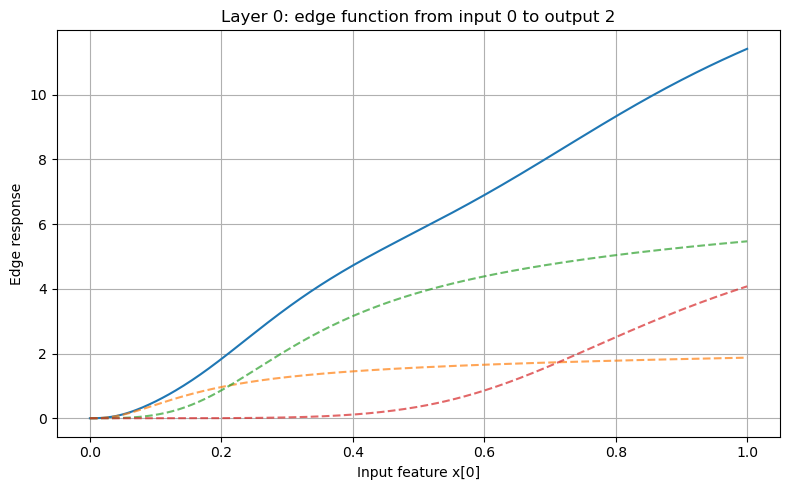

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out0_in1.mat


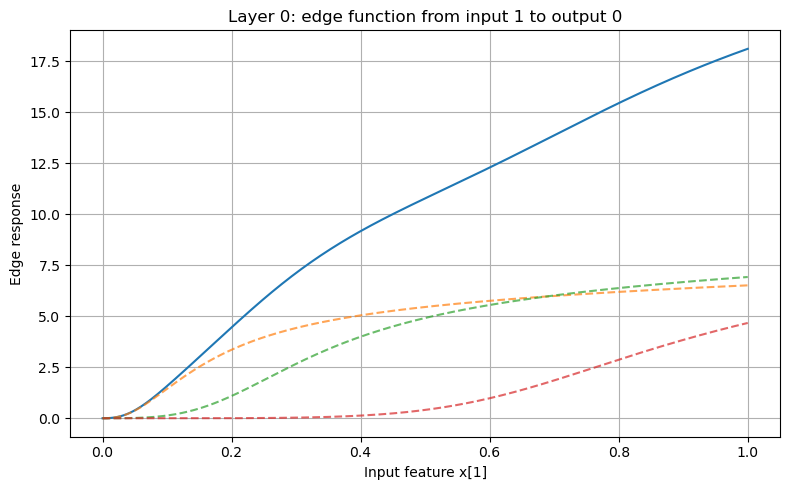

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out1_in1.mat


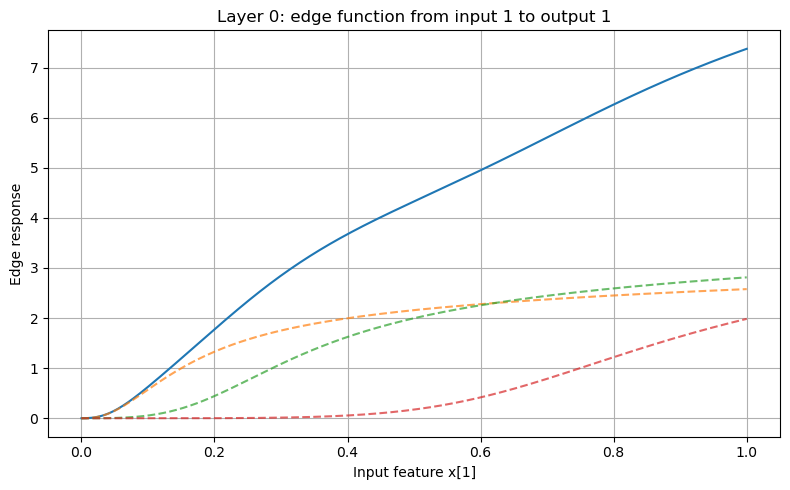

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out2_in1.mat


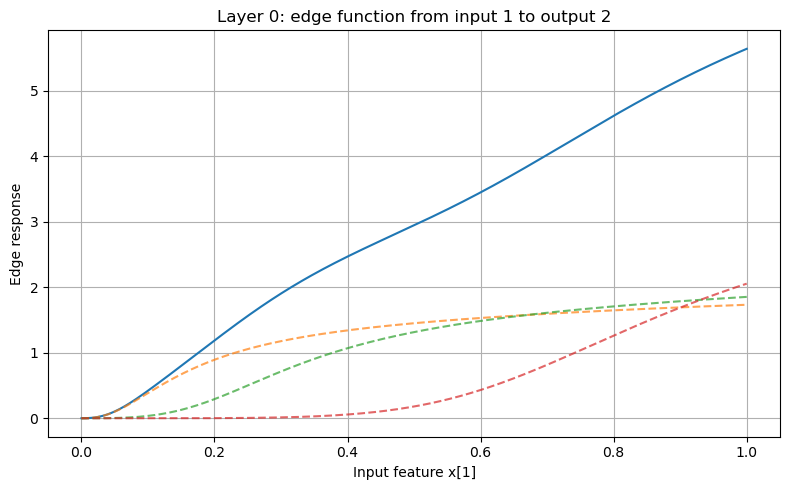

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out0_in2.mat


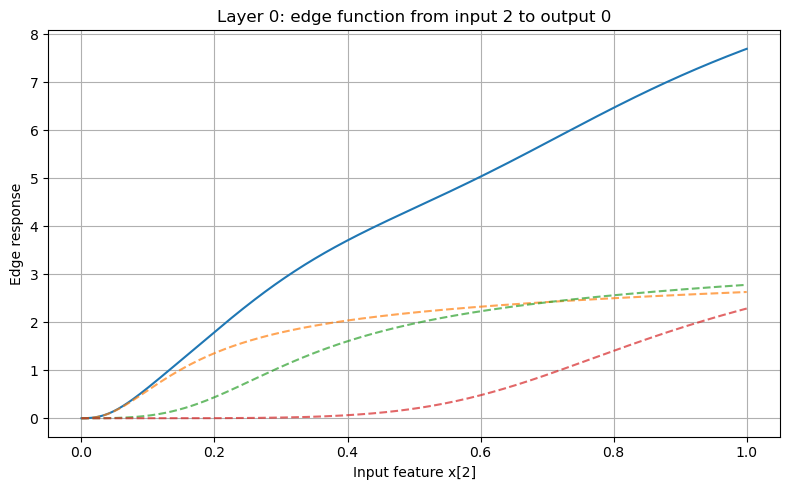

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out1_in2.mat


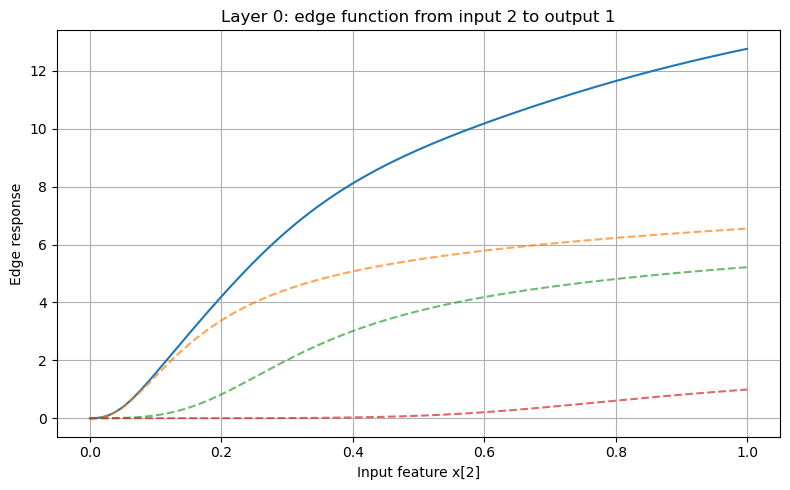

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out2_in2.mat


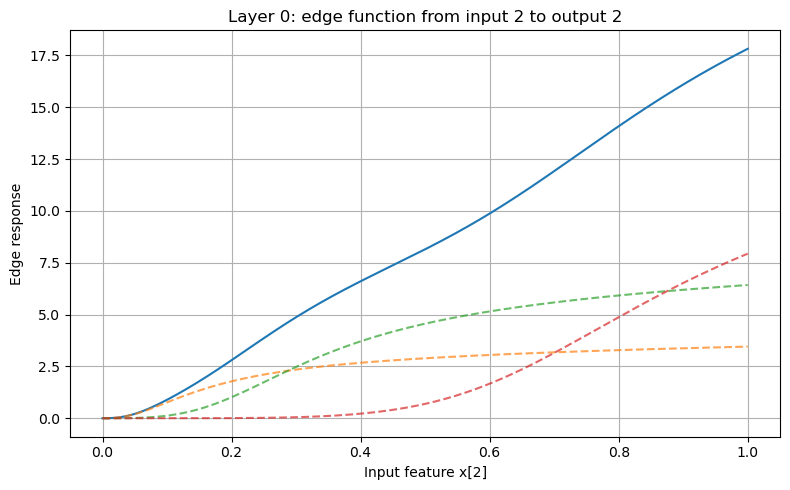

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out0_in3.mat


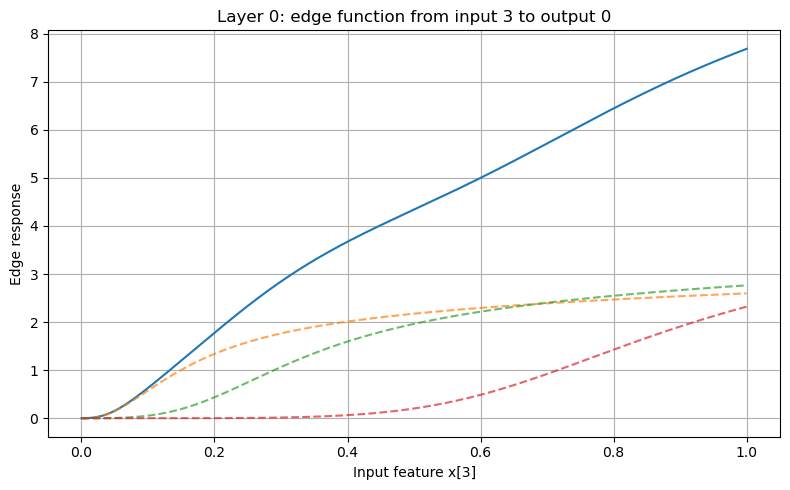

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out1_in3.mat


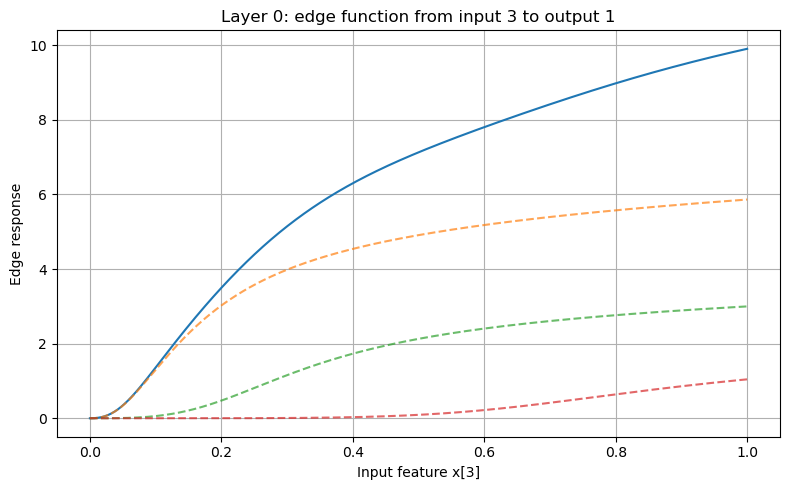

basis shape: torch.Size([400, 3])
basis finite: True
phi finite: True
Saved MATLAB plot data to: kan_iris_positive_export/edge_function_L0_out2_in3.mat


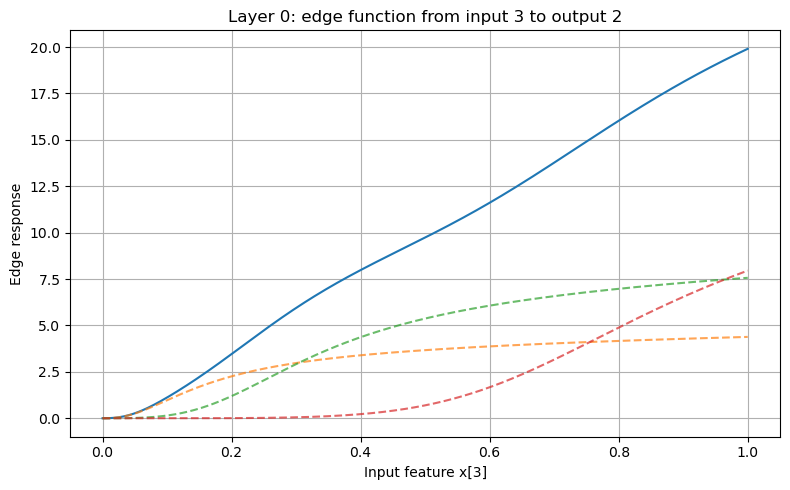

In [97]:
for in_idx in range(4):
    for out_idx in range(3):
        model.plot_edge_function(
            layer_idx=0,
            out_idx=out_idx,
            in_idx=in_idx,
            x_range=(x_min_physical, x_max_physical),
            show_basis=True,
            mat_export_path=f"edge_function_L0_out{out_idx}_in{in_idx}.mat",
            mat_export_dir=mat_folder,
        )

Input feature 0: sepal length (cm)
Saved MATLAB plot data to: kan_iris_positive_export/basis_functions_in0.mat


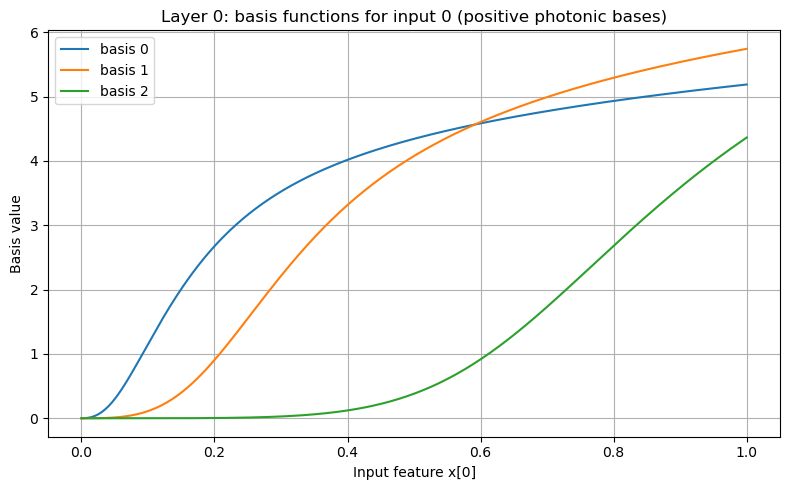

Input feature 1: sepal width (cm)
Saved MATLAB plot data to: kan_iris_positive_export/basis_functions_in1.mat


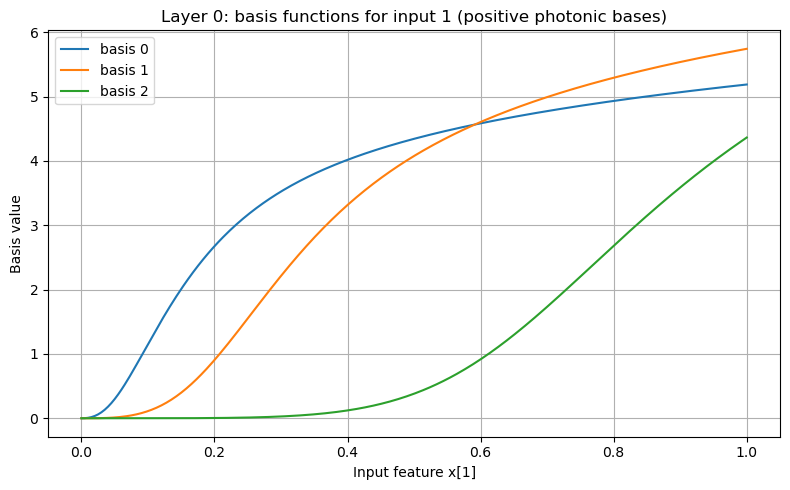

Input feature 2: petal length (cm)
Saved MATLAB plot data to: kan_iris_positive_export/basis_functions_in2.mat


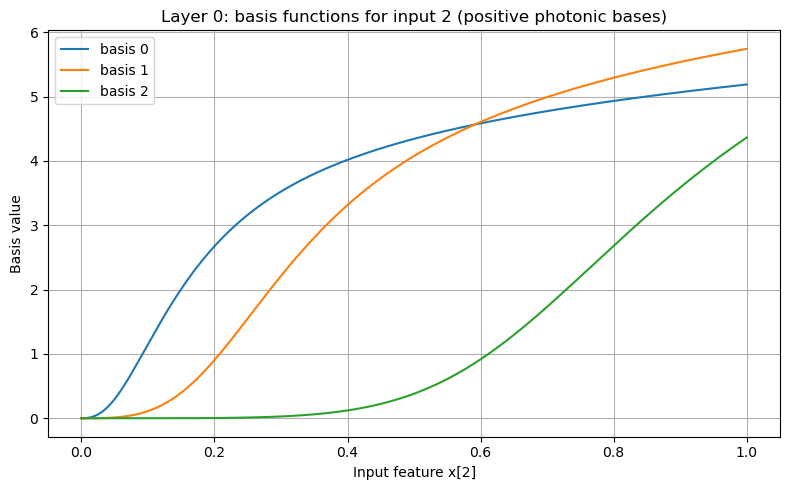

Input feature 3: petal width (cm)
Saved MATLAB plot data to: kan_iris_positive_export/basis_functions_in3.mat


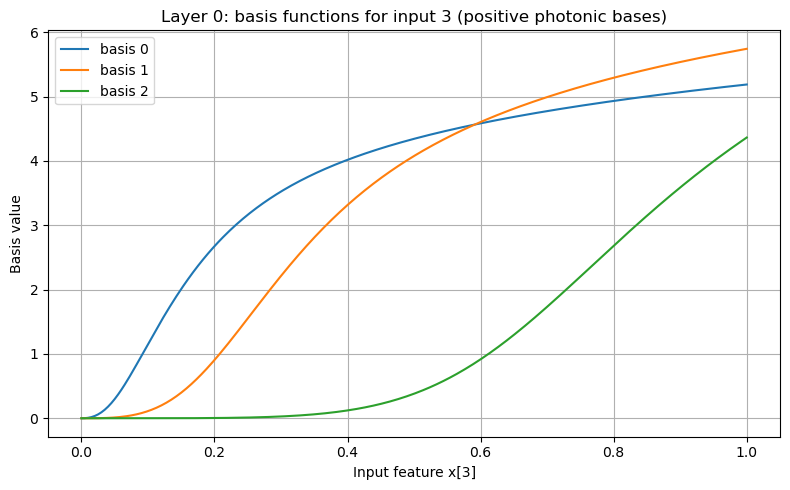

In [98]:
for in_idx, feature_name in enumerate(iris.feature_names):
    print(f"Input feature {in_idx}: {feature_name}")

    model.plot_basis_functions(
        layer_idx=0,
        in_idx=in_idx,
        x_range=(x_min_physical, x_max_physical),
        resolution=400,
        mat_export_path=f"basis_functions_in{in_idx}.mat",
        mat_export_dir=mat_folder,
    )

In [99]:
model.eval()

with torch.no_grad():
    logits = model(X_test_t)

print("Logits min:", logits.min().item())
print("Logits max:", logits.max().item())
print("First 10 logits:")
print(logits[:10])
print("First 10 predicted classes:")
print(torch.argmax(logits[:10], dim=1))
print("First 10 true classes:")
print(y_test_t[:10])

Logits min: 1.642122507095337
Logits max: 43.19832992553711
First 10 logits:
tensor([[11.0265,  4.8287,  3.2388],
        [29.0181, 33.4491, 31.9422],
        [22.5406, 28.2178, 24.8579],
        [16.2327, 24.8794, 22.3733],
        [ 9.7083,  4.2920,  2.8441],
        [28.7371, 32.4822, 30.6120],
        [23.5780, 31.1844, 31.4194],
        [31.6538, 36.7848, 41.2508],
        [31.1191, 37.5240, 42.0452],
        [28.6129, 34.8477, 40.0024]])
First 10 predicted classes:
tensor([0, 1, 1, 1, 0, 1, 2, 2, 2, 2])
First 10 true classes:
tensor([0, 1, 1, 1, 0, 1, 2, 2, 2, 2])


In [100]:
with torch.no_grad():
    logits = model(X_test_t)
    sorted_logits, _ = torch.sort(logits, dim=1, descending=True)
    margins = sorted_logits[:, 0] - sorted_logits[:, 1]

print("Margin min:", margins.min().item())
print("Margin mean:", margins.mean().item())
print("Margin max:", margins.max().item())

Margin min: 0.10651016235351562
Margin mean: 3.434293270111084
Margin max: 7.503140926361084


In [101]:
layer = model.layers[0]

x = torch.linspace(
    0.0,
    x_max_physical,
    400,
    dtype=layer.b_coef.dtype,
    device=layer.b_coef.device
)

x_expanded = x.view(-1, 1, 1, 1)

with torch.no_grad():
    basis = layer._photonic_basis(x_expanded)

print("basis min:", basis.min().item())
print("basis max:", basis.max().item())

basis min: 0.0
basis max: 5.743781566619873


In [102]:
layer = model.layers[0]
with torch.no_grad():
    coeffs_eff = layer.get_coeffs()

print("coeffs_eff min:", coeffs_eff.min().item())
print("coeffs_eff max:", coeffs_eff.max().item())
print("coeffs_eff mean:", coeffs_eff.mean().item())

coeffs_eff min: 0.22716908156871796
coeffs_eff max: 1.8228093385696411
coeffs_eff mean: 0.7815907597541809


## Matlab exports

In [103]:
import os
import numpy as np
import torch
import scipy.io as sio
from sklearn.metrics import confusion_matrix


def to_numpy(x):
    """
    Safely convert torch tensors, lists, scalars, or arrays to NumPy.
    """
    if x is None:
        return None

    if torch.is_tensor(x):
        return x.detach().cpu().numpy()

    return np.asarray(x)


def export_iris_photonic_positive_kan_to_mat(
    model,
    iris,
    scaler,
    X_train_original,
    X_test_original,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    selected_indices,
    b_coef,
    b_coef_selected,
    input_power,
    peakout_data,
    set_detuning,
    mat_filename="photonic_kan_iris_positive_export.mat",
    export_dir="kan_iris_positive_export",
    loss_history=None,
    acc_history=None,
    x_min_physical=0.0,
    x_max_physical=1.0,
    grid_resolution=400,
):
    """
    Export all relevant parameters and calculations for reproducing the
    photonic_positive KAN Iris experiment in MATLAB.

    Saved content includes:
      - Iris train/test data, original and scaled
      - scaler parameters
      - labels and class names
      - selected photonic basis indices
      - b_coef, b_coef_selected
      - input_power, peakout_data, set_detuning
      - train/test logits and predictions
      - train/test accuracy
      - confusion matrix
      - margin statistics
      - loss/accuracy history if provided
      - model architecture
      - per-layer raw_coeffs and effective positive coeffs
      - per-layer basis values, edge values, outputs
      - min/max diagnostics
      - basis values on a plotting grid
    """

    os.makedirs(export_dir, exist_ok=True)

    model.eval()

    device = next(model.parameters()).device

    data = {}

    # --------------------------------------------------
    # Convert data to tensors
    # --------------------------------------------------

    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=device)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)

    y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
    y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

    y_train_np = to_numpy(y_train).astype(np.int64)
    y_test_np = to_numpy(y_test).astype(np.int64)

    # --------------------------------------------------
    # Basic metadata
    # --------------------------------------------------

    data["model_description"] = np.array(
        ["Direct photonic positive KAN model for IRIS classification."],
        dtype=object,
    )

    data["model_type"] = np.array(
        ["photonic_positive KAN"],
        dtype=object,
    )

    data["task_type"] = np.array(
        ["classification"],
        dtype=object,
    )

    data["dataset_name"] = np.array(
        ["iris"],
        dtype=object,
    )

    data["layer_type"] = np.array(
        [model.layer_type],
        dtype=object,
    )

    data["in_count"] = np.array([[model.in_count]])
    data["out_count"] = np.array([[model.out_count]])
    data["num_layers"] = np.array([[len(model.layers)]])
    data["hidden_layer_sizes"] = np.asarray(model.hidden_layer_sizes, dtype=np.float64).reshape(1, -1)

    data["model_num_basis"] = np.array([[model.num_basis]])
    data["model_x_min"] = np.array([[model.x_min]])
    data["model_x_max"] = np.array([[model.x_max]])
    data["model_coeff_eps"] = np.array([[model.coeff_eps]])

    data["x_min_physical"] = np.array([[x_min_physical]])
    data["x_max_physical"] = np.array([[x_max_physical]])

    data["iris_feature_names"] = np.asarray(list(iris.feature_names), dtype=object).reshape(1, -1)
    data["iris_class_names"] = np.asarray(list(iris.target_names), dtype=object).reshape(1, -1)

    # --------------------------------------------------
    # Selected photonic basis information
    # --------------------------------------------------

    data["selected_indices_python"] = np.asarray(selected_indices, dtype=np.int64).reshape(1, -1)
    data["selected_indices_matlab"] = (
        np.asarray(selected_indices, dtype=np.int64).reshape(1, -1) + 1
    )

    data["selected_detunings"] = to_numpy(set_detuning)[selected_indices].reshape(1, -1)

    data["b_coef"] = to_numpy(b_coef)
    data["b_coef_selected"] = to_numpy(b_coef_selected)

    data["input_power"] = to_numpy(input_power)
    data["peakout_data"] = to_numpy(peakout_data)
    data["set_detuning"] = to_numpy(set_detuning)

    # --------------------------------------------------
    # Scaler parameters
    # --------------------------------------------------

    data["scaler_type"] = np.array(
        ["sklearn.preprocessing.MinMaxScaler"],
        dtype=object,
    )

    data["scaler_feature_range"] = np.asarray(
        scaler.feature_range,
        dtype=np.float64,
    ).reshape(1, -1)

    data["scaler_data_min"] = to_numpy(scaler.data_min_).reshape(1, -1)
    data["scaler_data_max"] = to_numpy(scaler.data_max_).reshape(1, -1)
    data["scaler_data_range"] = to_numpy(scaler.data_range_).reshape(1, -1)
    data["scaler_scale"] = to_numpy(scaler.scale_).reshape(1, -1)
    data["scaler_min"] = to_numpy(scaler.min_).reshape(1, -1)

    # --------------------------------------------------
    # Dataset
    # --------------------------------------------------

    data["X_train_original"] = to_numpy(X_train_original)
    data["X_test_original"] = to_numpy(X_test_original)

    data["X_train_scaled"] = to_numpy(X_train_scaled)
    data["X_test_scaled"] = to_numpy(X_test_scaled)

    # Compatibility aliases with your previous export style
    data["x_train"] = to_numpy(X_train_scaled)
    data["x_test"] = to_numpy(X_test_scaled)

    data["y_train"] = y_train_np.reshape(-1, 1)
    data["y_test"] = y_test_np.reshape(-1, 1)

    # --------------------------------------------------
    # Training curves, if available
    # --------------------------------------------------

    if loss_history is not None:
        data["loss_history"] = np.asarray(loss_history, dtype=np.float64).reshape(-1, 1)

    if acc_history is not None:
        data["acc_history"] = np.asarray(acc_history, dtype=np.float64).reshape(-1, 1)

    # --------------------------------------------------
    # PyTorch model predictions
    # --------------------------------------------------

    with torch.no_grad():
        train_logits_t = model(X_train_t)
        test_logits_t = model(X_test_t)

        train_pred_t = torch.argmax(train_logits_t, dim=1)
        test_pred_t = torch.argmax(test_logits_t, dim=1)

        train_acc = (train_pred_t == y_train_t).float().mean().item()
        test_acc = (test_pred_t == y_test_t).float().mean().item()

        sorted_test_logits, _ = torch.sort(test_logits_t, dim=1, descending=True)
        test_margins_t = sorted_test_logits[:, 0] - sorted_test_logits[:, 1]

    train_logits = to_numpy(train_logits_t)
    test_logits = to_numpy(test_logits_t)

    train_pred = to_numpy(train_pred_t).astype(np.int64)
    test_pred = to_numpy(test_pred_t).astype(np.int64)

    test_margins = to_numpy(test_margins_t)

    data["train_logits"] = train_logits
    data["test_logits"] = test_logits

    data["train_pred"] = train_pred.reshape(-1, 1)
    data["test_pred"] = test_pred.reshape(-1, 1)

    # Compatibility alias
    data["y_pred_test"] = test_pred.reshape(-1, 1)

    data["train_accuracy"] = np.array([[train_acc]], dtype=np.float64)
    data["test_accuracy"] = np.array([[test_acc]], dtype=np.float64)

    data["confusion_matrix_test"] = confusion_matrix(y_test_np, test_pred)

    data["test_margins"] = test_margins.reshape(-1, 1)
    data["test_margin_min"] = np.array([[test_margins.min()]], dtype=np.float64)
    data["test_margin_mean"] = np.array([[test_margins.mean()]], dtype=np.float64)
    data["test_margin_max"] = np.array([[test_margins.max()]], dtype=np.float64)

    data["logits_min"] = np.array([[test_logits.min()]], dtype=np.float64)
    data["logits_max"] = np.array([[test_logits.max()]], dtype=np.float64)

    # --------------------------------------------------
    # Manual forward pass for test set
    # --------------------------------------------------

    h = X_test_t

    with torch.no_grad():
        for layer_idx, layer in enumerate(model.layers):
            prefix = f"layer{layer_idx}"

            layer_input = h

            # This is exactly what PhotonicBasisActivationLayerPositive.forward uses.
            x_expanded = layer_input.unsqueeze(1).unsqueeze(-1)

            basis = layer._photonic_basis(x_expanded)

            raw_coeffs = layer.raw_coeffs
            coeffs_effective = layer.get_coeffs()

            coeffs_expanded = coeffs_effective.unsqueeze(0)

            edge_values = (coeffs_expanded * basis).sum(dim=-1)

            layer_output = edge_values.sum(dim=-1)

            # Save layer architecture
            data[f"{prefix}_in_count"] = np.array([[layer.in_count]])
            data[f"{prefix}_out_count"] = np.array([[layer.out_count]])
            data[f"{prefix}_num_basis"] = np.array([[layer.num_basis]])

            # Save layer configuration
            data[f"{prefix}_x_min"] = np.array([[layer.x_min]])
            data[f"{prefix}_x_max"] = np.array([[layer.x_max]])
            data[f"{prefix}_coeff_eps"] = np.array([[layer.coeff_eps]])

            if hasattr(layer, "normalize_basis"):
                data[f"{prefix}_normalize_basis"] = np.array([[int(layer.normalize_basis)]])

            if hasattr(layer, "check_input_range"):
                data[f"{prefix}_check_input_range"] = np.array([[int(layer.check_input_range)]])

            # Save fixed photonic basis coefficients
            data[f"{prefix}_b_coef"] = to_numpy(layer.b_coef)

            # Save trainable parameters
            data[f"{prefix}_raw_coeffs"] = to_numpy(raw_coeffs)

            # Save effective positive coefficients used in forward pass
            data[f"{prefix}_coeffs_effective"] = to_numpy(coeffs_effective)

            # Compatibility alias: these are the coefficients actually used
            data[f"{prefix}_coeffs"] = to_numpy(coeffs_effective)

            # Save forward-pass values
            data[f"{prefix}_input"] = to_numpy(layer_input)
            data[f"{prefix}_basis"] = to_numpy(basis)
            data[f"{prefix}_edge_values"] = to_numpy(edge_values)
            data[f"{prefix}_output"] = to_numpy(layer_output)

            # Save diagnostic stats
            data[f"{prefix}_min_input"] = np.array([[layer_input.min().item()]])
            data[f"{prefix}_max_input"] = np.array([[layer_input.max().item()]])

            data[f"{prefix}_min_basis"] = np.array([[basis.min().item()]])
            data[f"{prefix}_max_basis"] = np.array([[basis.max().item()]])

            data[f"{prefix}_min_raw_coeffs"] = np.array([[raw_coeffs.min().item()]])
            data[f"{prefix}_max_raw_coeffs"] = np.array([[raw_coeffs.max().item()]])

            data[f"{prefix}_min_coeffs_effective"] = np.array([[coeffs_effective.min().item()]])
            data[f"{prefix}_max_coeffs_effective"] = np.array([[coeffs_effective.max().item()]])
            data[f"{prefix}_mean_coeffs_effective"] = np.array([[coeffs_effective.mean().item()]])

            data[f"{prefix}_min_edge_values"] = np.array([[edge_values.min().item()]])
            data[f"{prefix}_max_edge_values"] = np.array([[edge_values.max().item()]])

            data[f"{prefix}_min_output"] = np.array([[layer_output.min().item()]])
            data[f"{prefix}_max_output"] = np.array([[layer_output.max().item()]])

            h = layer_output

    manual_test_logits = to_numpy(h)
    manual_test_pred = np.argmax(manual_test_logits, axis=1)

    max_abs_error = np.max(np.abs(test_logits - manual_test_logits))

    data["manual_test_logits"] = manual_test_logits
    data["manual_test_pred"] = manual_test_pred.reshape(-1, 1)
    data["manual_test_accuracy"] = np.array(
        [[np.mean(manual_test_pred == y_test_np)]],
        dtype=np.float64,
    )
    data["max_abs_error_pytorch_vs_manual_logits"] = np.array(
        [[max_abs_error]],
        dtype=np.float64,
    )

    # --------------------------------------------------
    # Basis values on plotting grid
    # --------------------------------------------------

    layer0 = model.layers[0]

    x_grid = torch.linspace(
        x_min_physical,
        x_max_physical,
        grid_resolution,
        dtype=layer0.b_coef.dtype,
        device=layer0.b_coef.device,
    )

    x_grid_expanded = x_grid.view(-1, 1, 1, 1)

    with torch.no_grad():
        basis_grid = layer0._photonic_basis(x_grid_expanded)

    data["basis_grid_x"] = to_numpy(x_grid).reshape(-1, 1)
    data["basis_grid_values"] = to_numpy(basis_grid)

    data["basis_grid_min"] = np.array([[basis_grid.min().item()]])
    data["basis_grid_max"] = np.array([[basis_grid.max().item()]])

    # --------------------------------------------------
    # Save MAT file
    # --------------------------------------------------

    mat_path = os.path.join(export_dir, mat_filename)

    sio.savemat(mat_path, data, do_compression=False)

    print(f"Saved export to: {mat_path}")
    print(f"Train accuracy: {train_acc:.12f}")
    print(f"Test accuracy:  {test_acc:.12f}")
    print(f"Max abs error PyTorch vs manual logits: {max_abs_error:.12e}")
    print("Exported variables:")
    for key in sorted(data.keys()):
        value = data[key]
        if isinstance(value, np.ndarray):
            print(f"  {key}: shape={value.shape}, dtype={value.dtype}")
        else:
            print(f"  {key}: type={type(value)}")

    return mat_path

In [104]:
mat_path = export_iris_photonic_positive_kan_to_mat(
    model=model,
    iris=iris,
    scaler=scaler,
    X_train_original=X_train_original,
    X_test_original=X_test_original,
    X_train_scaled=X_train_scaled,
    X_test_scaled=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    selected_indices=selected_indices,
    b_coef=b_coef,
    b_coef_selected=b_coef_selected,
    input_power=input_power,
    peakout_data=peakout_data,
    set_detuning=set_detuning,
    mat_filename="photonic_kan_iris_positive_export.mat",
    export_dir="kan_iris_positive_export",
    loss_history=loss_history,
    acc_history=acc_history,
    x_min_physical=x_min_physical,
    x_max_physical=x_max_physical,
    grid_resolution=400,
)

Saved export to: kan_iris_positive_export/photonic_kan_iris_positive_export.mat
Train accuracy: 0.973214268684
Test accuracy:  0.973684191704
Max abs error PyTorch vs manual logits: 0.000000000000e+00
Exported variables:
  X_test_original: shape=(38, 4), dtype=float64
  X_test_scaled: shape=(38, 4), dtype=float64
  X_train_original: shape=(112, 4), dtype=float64
  X_train_scaled: shape=(112, 4), dtype=float64
  acc_history: shape=(3000, 1), dtype=float64
  b_coef: shape=(34, 8), dtype=float32
  b_coef_selected: shape=(3, 8), dtype=float32
  basis_grid_max: shape=(1, 1), dtype=float64
  basis_grid_min: shape=(1, 1), dtype=float64
  basis_grid_values: shape=(400, 1, 1, 3), dtype=float32
  basis_grid_x: shape=(400, 1), dtype=float32
  confusion_matrix_test: shape=(3, 3), dtype=int64
  dataset_name: shape=(1,), dtype=object
  hidden_layer_sizes: shape=(1, 0), dtype=float64
  in_count: shape=(1, 1), dtype=int64
  input_power: shape=(180,), dtype=float32
  iris_class_names: shape=(1, 3), dty